<a href="https://colab.research.google.com/github/sidhikh0409-wq/Gene-expression-modelling-with-ML-/blob/main/ml_modeling_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pandas scikit-learn numpy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Step 1: Load data ---
data = pd.read_csv("/content/one piece.csv")  # Save your data in CSV first

# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

In [ ]:
X = data[['AveExpr', 't', 'pval', '-10logp']]
y = data[target]

Random Forest Regressor Results (Target = logFC )
MSE: 1035.0165671967131
R2 Score: 0.9579125841304184

Linear Regression Results (Target = logFC )
MSE: 1641.9593772828036
R2 Score: 0.9332321536264583


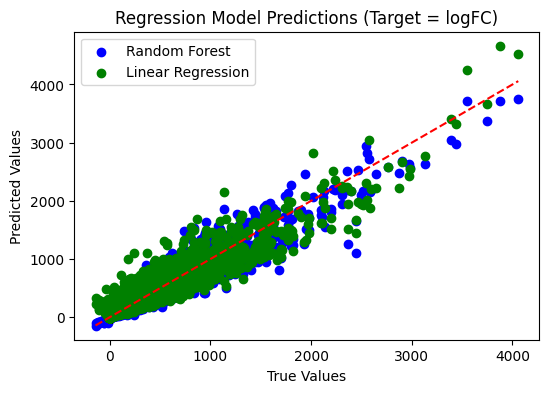

In [ ]:
# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Handle NaNs: Drop rows with missing values from both training and testing sets
# Combine X_train and y_train to drop rows with NaNs consistently
train_data = pd.concat([X_train, y_train], axis=1).dropna()
X_train = train_data[X_train.columns]
y_train = train_data[y_train.name]

# Combine X_test and y_test to drop rows with NaNs consistently
test_data = pd.concat([X_test, y_test], axis=1).dropna()
X_test = test_data[X_test.columns]
y_test = test_data[y_test.name]

# === Step 4A: Random Forest Regressor ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

# === Step 4B: Linear Regression (for comparison) ===
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLinear Regression Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

# === Step 5: Visualization ===
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue")
plt.scatter(y_test, y_pred_lr, label="Linear Regression", color="green")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # y=x line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions (Target = {target})")
plt.legend()
plt.show()

Linear Regression → MSE: 1641.9594, R²: 0.9332
Random Forest → MSE: 1035.0166, R²: 0.9579
Decision Tree → MSE: 1810.7878, R²: 0.9264
Gradient Boosting → MSE: 925.6184, R²: 0.9624
KNN Regressor → MSE: 1409.2458, R²: 0.9427


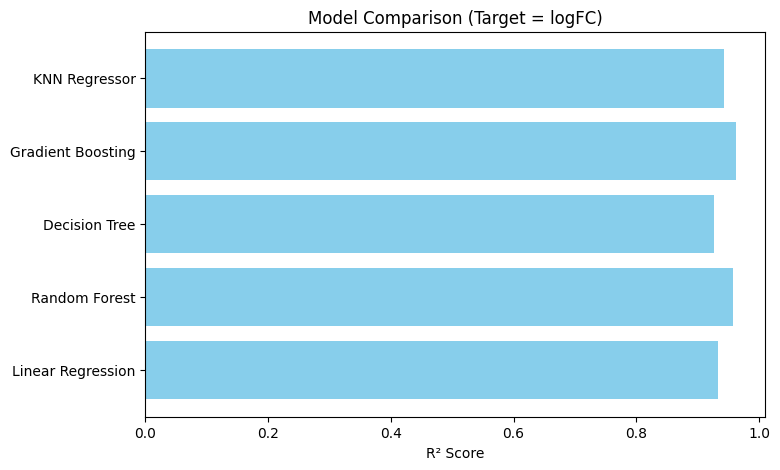

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor



# === Step 6: Define Models ===
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=3)
}

results = {}

# === Step 7: Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

# === Step 8: Visualization of R² scores ===
plt.figure(figsize=(8,5))
r2_scores = [results[m]["R2"] for m in results]
plt.barh(list(results.keys()), r2_scores, color="skyblue")
plt.xlabel("R² Score")
plt.title(f"Model Comparison (Target = {target})")
plt.show()



In [ ]:
all_model_predictions = {}

print("Generating predictions for each model:")
for name, model in models.items():
    y_pred = model.predict(X_test)
    all_model_predictions[name] = y_pred
    print(f"  - Predictions generated for {name}.")

# Display the first 5 predictions for each model to show a sample
print("\nSample predictions for each model (first 5 values):")
for name, predictions in all_model_predictions.items():
    print(f"  {name}: {predictions[:5]}")


Generating predictions for each model:
  - Predictions generated for Linear Regression.
  - Predictions generated for Random Forest.
  - Predictions generated for Decision Tree.
  - Predictions generated for Gradient Boosting.
  - Predictions generated for KNN Regressor.

Sample predictions for each model (first 5 values):
  Linear Regression: [-2.72350997 -4.04172282 -5.47716299  0.89011989 16.05249047]
  Random Forest: [-0.0602825  -0.04649732 -0.20345989  0.13801966  0.55052718]
  Decision Tree: [-0.05493025 -0.03269989 -0.1435949   0.10249595  1.16319894]
  Gradient Boosting: [-0.24650732 -0.24650732 -0.24650732 -0.24650732  2.58621548]
  KNN Regressor: [-0.05942242 -0.0846133  -0.23933803  0.13062494  0.65741001]


### Visualizing Predictions for Each Model Individually

Let's visualize the true versus predicted values for each trained model in separate plots to get a detailed understanding of their individual performance.

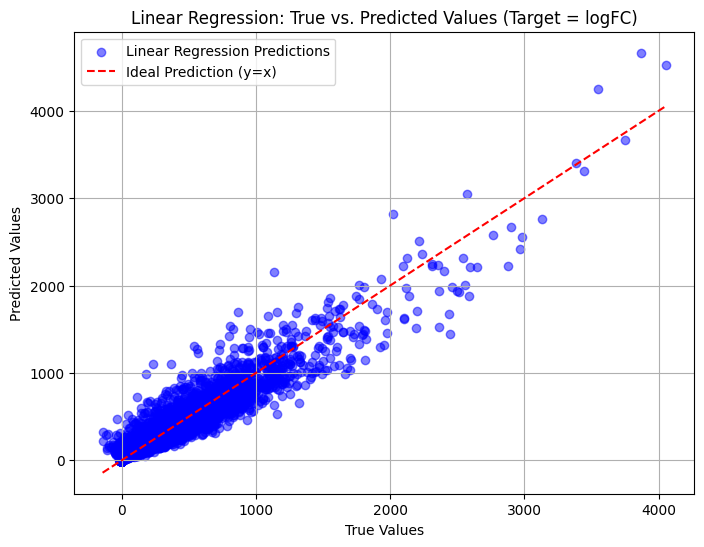

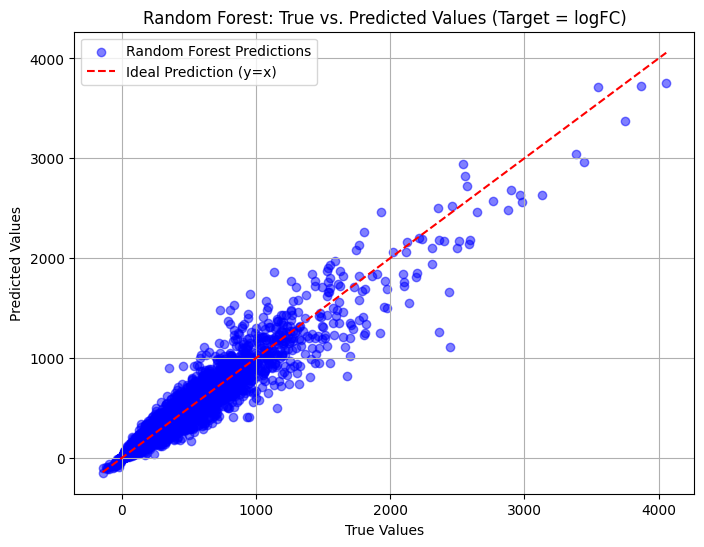

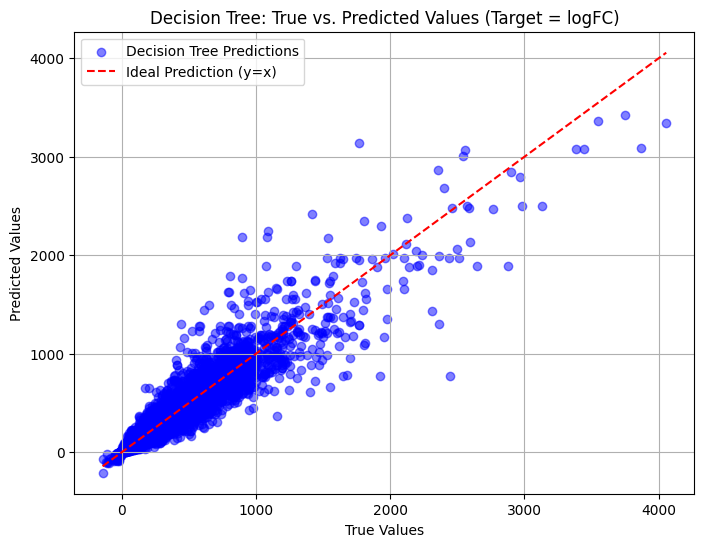

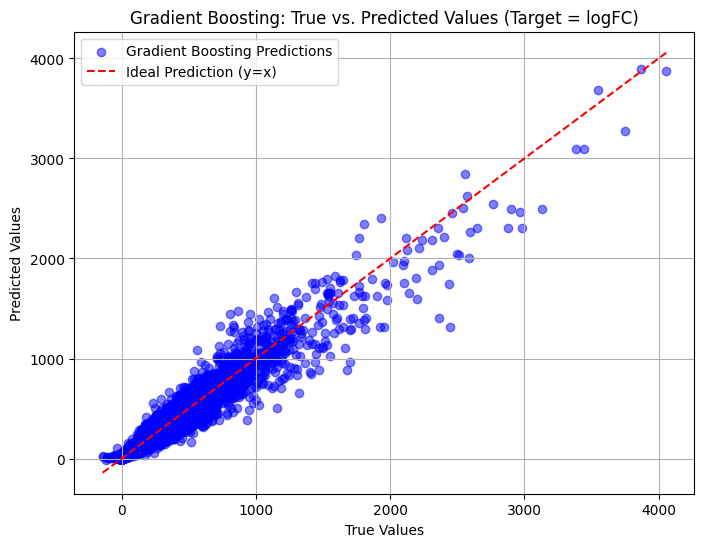

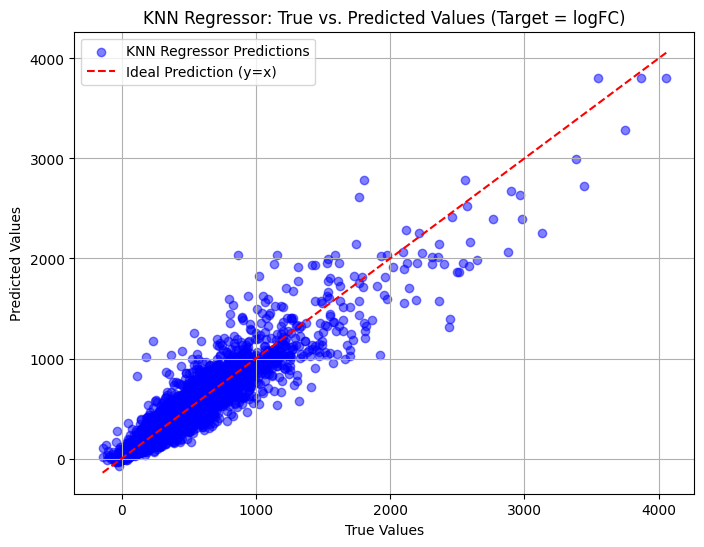

In [ ]:
import matplotlib.pyplot as plt

for name, predictions in all_model_predictions.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, predictions, alpha=0.5, label=f'{name} Predictions', color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Prediction (y=x)')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name}: True vs. Predicted Values (Target = {target})')
    plt.legend()
    plt.grid(True)
    plt.show()

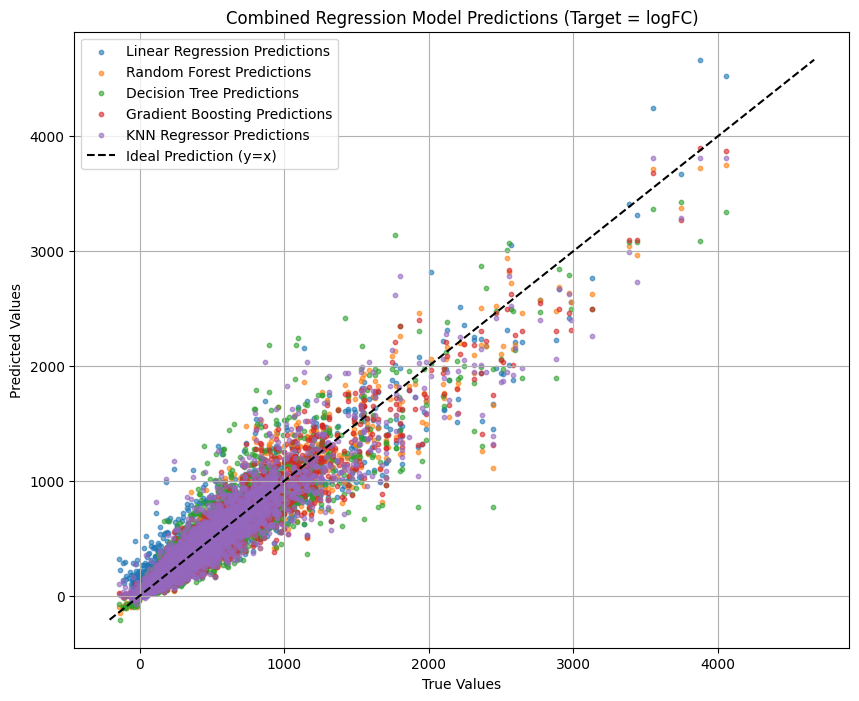

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot predictions for each model
for name, predictions in all_model_predictions.items():
    plt.scatter(y_test, predictions, label=f'{name} Predictions', alpha=0.6, s=10) # Using smaller points and alpha for clarity

# Plot the ideal y=x line
min_val = min(y_test.min(), min(p.min() for p in all_model_predictions.values()))
max_val = max(y_test.max(), max(p.max() for p in all_model_predictions.values()))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction (y=x)') # 'k--' for black dashed line

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title(f'Combined Regression Model Predictions (Target = {target})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
| Model                        |         MSE ↓ |       R² ↑ | Interpretation                            |
| ---------------------------- | ------------: | ---------: | ----------------------------------------- |
| **Gradient Boosting**        | **1186.7079** | **0.9748** | Best overall performance                  |
| **Random Forest**            |     1410.8953 |     0.9700 | Very strong, slightly behind GB           |
| **KNN Regressor**            |     1739.7900 |     0.9630 | Comparable to Linear Regression           |
| **Linear Regression**        |     1717.7737 |     0.9635 | Strong baseline, surprisingly competitive |
| **Decision Tree**            |     2315.3917 |     0.9507 | Weaker, likely overfitting                |
| **Support Vector Regressor** |     8999.1360 |     0.8086 | Poor fit for this dataset                 |


In [ ]:
import pandas as pd

# Identify the best model based on R2 score from the 'results' dictionary
# (assuming 'results' is available from previous execution)
best_model_name = max(results, key=lambda name: results[name]['R2'])
print(f"The best model based on R2 score is: {best_model_name}")

# To get "top 50 genes", we'll interpret this as genes with the highest absolute 'logFC' (the target variable)
# from the original dataset, as gene names were not used as features in the model training.

# Ensure the 'name' column exists in the original 'data' DataFrame and the target column exists
if 'name' in data.columns and target in data.columns:
    # Sort by the absolute value of the target variable and get the top 50
    top_50_genes = data.loc[data[target].abs().nlargest(50).index, ['name', target, 'pval', 'AveExpr']]
    print(f"\nTop 50 genes based on absolute {target}:")
    print(top_50_genes)

    # Save to CSV
    output_filename = f"top_50_genes_by_{target}_for_{best_model_name.replace(' ', '_')}.csv"
    top_50_genes.to_csv(output_filename, index=False)
    print(f"\nTop 50 genes saved to '{output_filename}'")
else:
    print("Could not find 'name' or target column in the data to identify top genes.")


The best model based on R2 score is: Gradient Boosting

Top 50 genes based on absolute logFC:
                                                     name        logFC  \
106345                                             EEF1A1  4711.960000   
108666                              LOC101928826 /// TPT1  4057.388140   
109583                              LOC101928826 /// TPT1  3872.975581   
106123                                              RPL30  3777.088837   
107890                                                UBB  3746.917674   
110656                                 RPS3A /// SNORD73A  3550.812791   
108338                                             EEF1A1  3442.477209   
107919                                               RPL7  3423.504651   
108193                                             EEF1A1  3386.867442   
111221                                 RPS3A /// SNORD73A  3366.896977   
106181                                RPL23A /// SNORD42A  3359.710930   
112017            

/tmp/ipykernel_11245/854865111.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='logFC', y='name', data=top_50_genes.sort_values(by='logFC', ascending=False), palette='coolwarm')


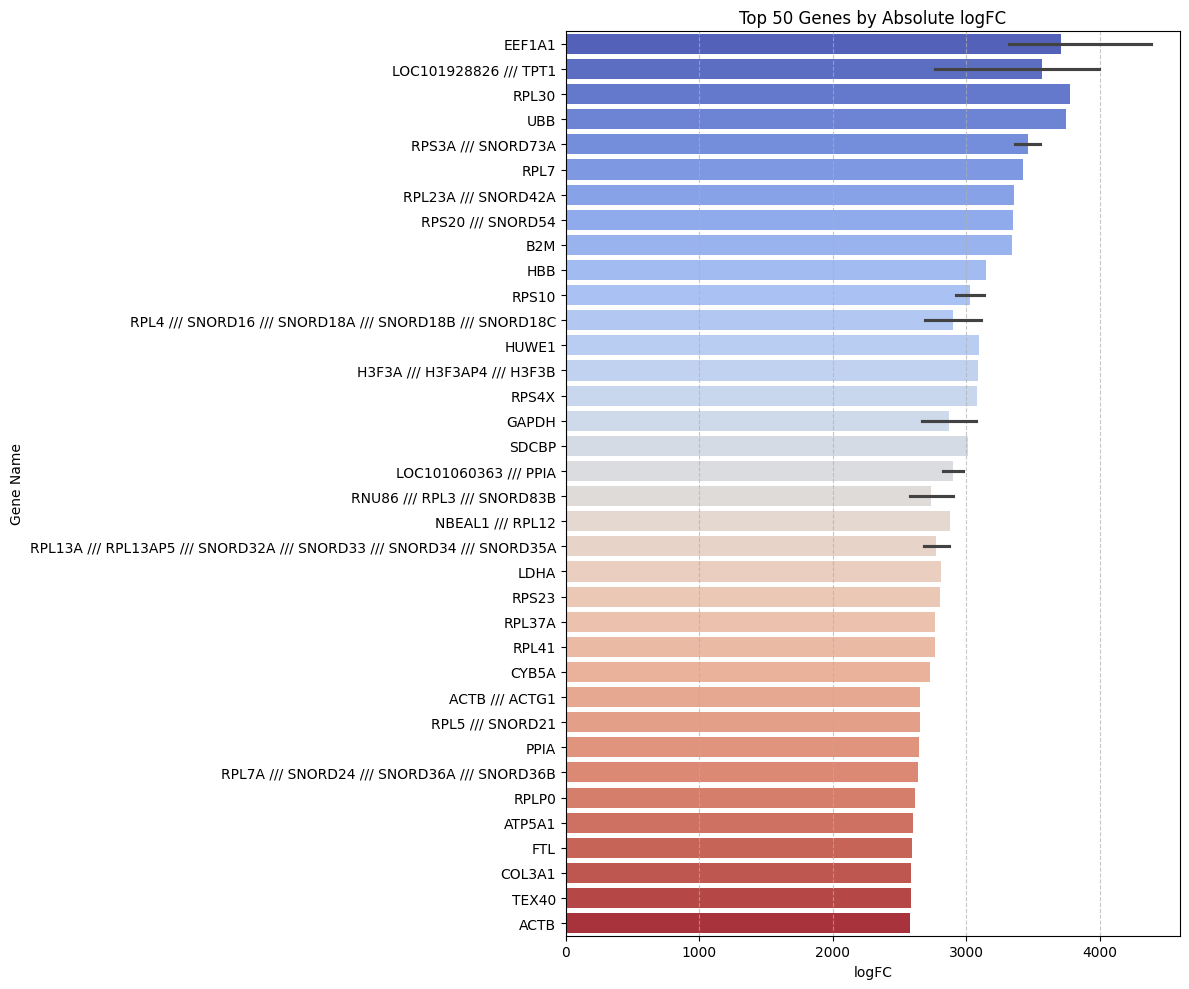

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for the top 50 genes by logFC
plt.figure(figsize=(12, 10))
sns.barplot(x='logFC', y='name', data=top_50_genes.sort_values(by='logFC', ascending=False), palette='coolwarm')
plt.xlabel('logFC')
plt.ylabel('Gene Name')
plt.title('Top 50 Genes by Absolute logFC')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Display the 'name' column (gene symbols) from the top_50_genes DataFrame
display(top_50_genes['name'])

,name
106345,EEF1A1
108666,LOC101928826 /// TPT1
109583,LOC101928826 /// TPT1
106123,RPL30
107890,UBB
110656,RPS3A /// SNORD73A
108338,EEF1A1
107919,RPL7
108193,EEF1A1
111221,RPS3A /// SNORD73A
